## Interactive Bayesian Optimization (w/UCB Acquisition) for Function 3

Note: This code recommends the next point based on historical data.

Submit the recommended point to the Capstone project portal, obtain the output, then update `input.npy` and `output.npy`.

You’re working on a drug discovery project, testing combinations of three compounds to create a new medicine.Each experiment is stored in initial_inputs.npy as a 3D array, where each row lists the amounts of the three compounds used. After each experiment, you record the number of adverse reactions 不良反应, stored in initial_outputs.npy as a 1D array.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
# from sklearn.gaussian_process.kernels import ConstantKernel
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm
import os

In [2]:
# Load and check initial data

# Initial INPUT file path
X_init = np.load(r"initial_data\function_3\initial_inputs.npy")
# Initial OUTPUT file path
y_init = np.load(r"initial_data\function_3\initial_outputs.npy")

# INPUT file storing historical inputs 3D array (n, dim)
input_file = r"initial_data\function_3\inputs.npy"
# INPUT file storing historical outputs 1D array (n, )
output_file = r"initial_data\function_3\outputs.npy"

if os.path.exists(input_file) and os.path.exists(output_file):
    print(f"Historical INPUT contains {len(np.load(input_file))} points:\n", np.load(input_file))
    print(f"Historical OUTPUT contains {len(np.load(output_file))} points:\n", np.load(output_file))
else:
    print(f"Initial INPUT contains {len(X_init)} points:\n", X_init)
    print(f"Initial INPUT contains {len(y_init)} points:\n", y_init)

Historical INPUT contains 27 points:
 [[0.17152521 0.34391687 0.2487372 ]
 [0.24211446 0.64407427 0.27243281]
 [0.53490572 0.39850092 0.17338873]
 [0.49258141 0.61159319 0.34017639]
 [0.13462167 0.21991724 0.45820622]
 [0.34552327 0.94135983 0.26936348]
 [0.15183663 0.43999062 0.99088187]
 [0.64550284 0.39714294 0.91977134]
 [0.74691195 0.28419631 0.22629985]
 [0.17047699 0.6970324  0.14916943]
 [0.22054934 0.29782524 0.34355534]
 [0.66601366 0.67198515 0.2462953 ]
 [0.04680895 0.23136024 0.77061759]
 [0.60009728 0.72513573 0.06608864]
 [0.96599485 0.86111969 0.56682913]
 [0.23942784 0.32898746 0.89563405]
 [0.         0.939393   0.999999  ]
 [0.05737301 0.8148291  0.91677249]
 [0.07204763 0.94030562 0.99743845]
 [0.03556045 0.99916577 0.99384877]
 [0.01940476 0.97930522 0.98944699]
 [0.18189173 0.50053451 0.9927667 ]
 [0.0084829  0.55328453 0.95248147]
 [0.18114727 0.95935562 0.98494776]
 [0.49508334 0.96344514 0.99999679]
 [0.43095572 0.83145487 0.99883169]
 [0.49004699 0.91570203 0.

In [3]:
# 1. Configuration

# INPUT dimensionality
dim = 3
len_init = len(X_init)

# Bounds for each dimension
bounds = np.array([[0, 0.999999]] * dim)

# Number of candidate points
n_candidates = 1000

rbf_lengthscale = 0.1
noise_assumption = 1e-10
beta = 1.96
np.random.seed(23)

**Apr. 11<sup>th</sup>** (before 2<sup>nd</sup> submission)

- Conduct a grid research if the optimal output has not improved over several queries and exploration is insufficient.
- Alternate between UCB and EI if exploration seems insufficient.

In [4]:
# Grid density for grid search
grid_density = 100
use_grid_search = False    # 'True' or 'False'
# Acquisition type
acquisition_type = 'ucb'    # 'ucb' or 'ei'

In [5]:
# 2. Helper functions

# Load historical data from input.npy and output.npy
def load_data():
    if os.path.exists(input_file) and os.path.exists(output_file):
        print("Load historical data")
        X = np.load(input_file)
        y = np.load(output_file)
        # ensure dimensions match
        if X.shape[0] != y.shape[0]:
            raise ValueError(f"input.npy and output.npy mismatch: {X.shape[0]} vs {y.shape[0]}")
        return X, y
    else:
        print("Load initial data")
        X = X_init
        y = y_init
        return X, y

# Save historical data to input.npy and output.npy
def save_data(X, y):
    y_raw = -y
    np.save(input_file, X)
    np.save(output_file, y_raw)

# Upper Confidence Bound (UCB) acquisition function
def ucb_acquisition(x_cand, model, beta):
    post_mean, post_std = model.predict(x_cand, return_std = True)
    # avoid zero standard deviation
    post_std = np.maximum(post_std, 1e-9)
    return post_mean + beta * post_std

# Recommend the next point to evaluate
def suggest_next_point(X, y, trust_region, beta):
    # 20260428, add white noise
    kernel = RBF(length_scale = rbf_lengthscale, length_scale_bounds = (0.01, 10.0)) \
             + WhiteKernel(noise_level = 1e-5, noise_level_bounds = (1e-8, 1e-1))
    model = GaussianProcessRegressor(kernel = kernel, alpha = 1e-6, normalize_y = True, n_restarts_optimizer = 10)
    model.fit(X, y)
    
    # Generate candidate points
    #candidates = np.random.uniform(bounds[:, 0], bounds[:, 1], size = (n_candidates, dim))
    candidates = samples_in_trust_region(trust_region, n_candidates)
    # Exclude points that have already been evaluated
    from sklearn.neighbors import NearestNeighbors
    neighbors = NearestNeighbors(n_neighbors = 1, algorithm = 'auto').fit(X)
    distances, _ = neighbors.kneighbors(candidates)
    mask = distances.flatten() > 1e-6
    candidates = candidates[mask]

    print("Use Upper Confidence Bound (UCB) acquisition function within Trust Region.")
    ucb_values = ucb_acquisition(candidates, model, beta)
    next_idx = np.argmax(ucb_values)
    x_next = candidates[next_idx]
    mean, std = model.predict(x_next.reshape(1,-1), return_std = True)
    print(f"Predicted mean = {mean[0]:.6f}, std = {std[0]:.6f}, UCB = {mean[0] + beta * std[0]:.6f}")
    return x_next, ucb_values[next_idx]

# Plot optimization progress
def plot_progress(X, y, beta):
    #best_so_far = np.maximum.accumulate(y)
    plt.figure(figsize = (8, 4))
    #plt.plot(range(1, len(best_so_far) + 1), best_so_far, 'b-o', markersize = 4)
    plt.plot(range(1, len(y) + 1), y, 'b-o', markersize = 4)
    plt.xlabel('Number of evaluations')
    #plt.ylabel('Best Output found so far')
    plt.ylabel('Every Output found so far')
    plt.title('Optimization Progress (UCB, β={})'.format(beta, beta))
    plt.grid(True)
    plt.show()

# Convert an integer into its ordinal string
def ordinal(n):
    if 10 <= n % 100 <= 20:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(n % 10, 'th')
    return f"{n}{suffix}"

**Apr. 11<sup>th</sup>** (before 2<sup>nd</sup> submission)

- Define a function to check whether the optimal output has been unimproved over several queries.
- Define a grid research function to find the point that maximizes the acquisition function.
- Increase `length_scale` of the kernel function to try to improve the fitness of model.

In [6]:
# Check if the optimal output has been unimproved
def check_unimproved(y, window = 3, tolerance = 1e-6):
    y_accumulate = np.maximum.accumulate(y)
    recent_best = y_accumulate[-window: ]
    return (np.max(recent_best) - np.min(recent_best)) < tolerance


# Define a grid search function
def grid_search_acquisition(X, y, bounds, grid_density, acquisition_type, xi = 0.01):
    # Generate grid
    axes = [np.linspace(bounds[d, 0], bounds[d, 1], grid_density) for d in range(dim)]
    mesh = np.array(np.meshgrid(*axes)).T.reshape(-1, dim)

    # Retrain the GP model
    # 20260428, add white noise
    kernel = RBF(length_scale = rbf_lengthscale, length_scale_bounds = (0.01, 10.0)) \
             + WhiteKernel(noise_level = 1e-5, noise_level_bounds = (1e-6, 1e-1))
    model = GaussianProcessRegressor(kernel = kernel, alpha = 0.0)
    model.fit(X, y)

    # Compute acquisition value
    if acquisition_type == 'ucb':
        print("Use Upper Confidence Bound (UCB) acquisition function.")
        mesh_mean, mesh_std = model.predict(mesh, return_std = True)
        # avoid zero standard deviation
        mesh_std = np.maximum(mesh_std, 1e-9)
        acquisition_value = mesh_mean + beta * mesh_std
    elif acquisition_type == 'ei':
        print("Use Expected Improvement (EI) acquisition function.")
        mesh_mean, mesh_std = model.predict(mesh, return_std = True)
        mesh_std = np.maximum(mesh_std, 1e-9)
        y_max = np.max(y)
        z = (mesh_mean - y_max - xi) / mesh_std
        acquisition_value = (mesh_mean - y_max - xi) * norm.cdf(z) + mesh_std * norm.pdf(z)
    else:
        raise ValueError("acquisition_type must be 'ucb' or 'ei'")

    next_idx = np.argmax(acquisition_value)
    mean, std = model.predict(mesh[next_idx].reshape(1,-1), return_std = True)
    print(f"Predicted mean = {mean[0]:.6f}, std = {std[0]:.6f}, UCB = {mean[0] + beta * std[0]:.6f}")
    return mesh[next_idx], acquisition_value[next_idx]

**May. 11<sup>th</sup>** (before 5<sup>th</sup> submission)

- Define functions to implement the Trust Region approach. <br>Based on the current optimal output point, define a hypercube Trust Region. If the optimal outputs improve continuously, expand the radius; if no improvement, reduce the radius.

In [7]:
trust_region_file = r"initial_data\function_3\trust_region.npy"

def load_trust_region(X, y, filename = trust_region_file):
    if os.path.exists(filename):
        region = np.load(filename, allow_pickle = True).item()
        best_so_far = X[np.argmax(y)]
        if not np.array_equal(region['center'], best_so_far):
            region['center'] = best_so_far.copy()
        return region
    else:
        center = X[np.argmax(y)]
        print("Create initial Trust Region.")
        return {
            'center': center.copy(),
            'radius': 0.1,
            'bounds': bounds,
            'improvement_counter': 0,
            'unimprovement_counter': 0
        }

'''
def init_trust_region(center, radius = 0.1, bounds = bounds):
    return {
        'center': center.copy(),
        'radius': radius,
        'bounds': bounds,
        'improvement_counter': 0,
        'unimprovement_counter': 0
    }
'''

def save_trust_region(region, filename = trust_region_file):
    region_to_save = {
        'center': region['center'],
        'radius': region['radius'],
        'bounds': region['bounds'],
        'improvement_counter': region['improvement_counter'],
        'unimprovement_counter': region['unimprovement_counter']
    }
    np.save(filename, region_to_save, allow_pickle=True)
    print("Trust Region file is updated.")


def update_trust_region(region, new_center, improved = False):
    region['center'] = new_center.copy()
    if improved:
        region['improvement_counter'] += 1
        region['unimprovement_counter'] = 0
        if region['improvement_counter'] >= 2:
            region['radius'] = max(region['radius'] * 0.8, 0.05)
            print(f"Trust Region shrunk to radius {region['radius']:.4f}")
            region['improvement_counter'] = 0
    else:
        region['unimprovement_counter'] += 1
        region['improvement_counter'] = 0
        if region['unimprovement_counter'] >= 2:
            region['radius'] = min(region['radius'] * 1.5, 0.5)
            print(f"Trust Region expanded to radius {region['radius']:.4f}")
            region['unimprovement_counter'] = 0
    save_trust_region(region)

def samples_in_trust_region(region, n_points):
    n_local = int(n_points * 0.2)
    n_global = n_points - n_local
    lower = np.maximum(region['center'] - region['radius'], region['bounds'][:, 0])
    upper = np.minimum(region['center'] + region['radius'], region['bounds'][:, 1])
    lower = np.clip(lower, region['bounds'][:, 0], region['bounds'][:, 1])
    upper = np.clip(upper, region['bounds'][:, 0], region['bounds'][:, 1])
    local_samples = np.random.uniform(lower, upper, size = (n_local, dim))
    global_samples = np.random.uniform(region['bounds'][:, 0], region['bounds'][:,1], size = (n_global, dim))
    return np.vstack([local_samples, global_samples])

Load historical data
Loaded 27 points. And the historical OUTPUT:
 [0.1121222  0.08796286 0.11141465 0.03483531 0.04800758 0.11062091
 0.39892551 0.11386851 0.13146061 0.09418956 0.04694741 0.10596504
 0.11804826 0.03637783 0.05675837 0.08091761 0.46730182 0.11813326
 0.44976836 0.45415903 0.43620532 0.41099705 0.22741557 0.40776564
 0.47243626 0.44897037 0.07399694]
Current best output: 0.472436


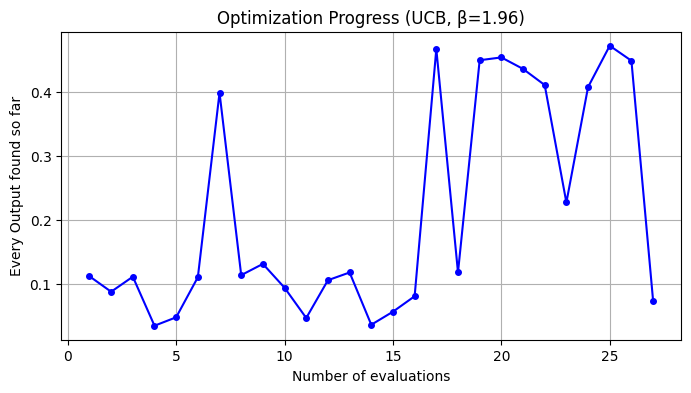

In [8]:
# 3. Load historical data and view current status
X, y = load_data()
y = -y

print(f"Loaded {len(X)} points. And the historical OUTPUT:\n", y)

if len(y) > 0:
    previous_best = np.max(y)
    print(f"Current best output: {np.max(y):.6f}")
    plot_progress(X, y, beta)
else:
    print("Please load initial data")

**Apr. 11<sup>th</sup>** (before 2<sup>nd</sup> submission)

Check whether the optimal output has been unimproved over several queries. If yes, execute the grid research function.

In [9]:
# 4. Recommend the next point to submit

trust_region = load_trust_region(X, y)
print(f"Trust region center: {trust_region['center']}, radius: {trust_region['radius']:.4f}")

if check_unimproved(y) & use_grid_search:
    print("Detect output has been unimproved over several queries. Use grid research for exploration.")
    x_next, best_acquisition_value = grid_search_acquisition(X, y, bounds, grid_density, acquisition_type)
    print(f"Grid search selected point with acquisition value: {best_acquisition_value:.6f}")
else:
    x_next, best_acquisition_value = suggest_next_point(X, y, trust_region, beta)
    print(f"GP selected point with acquisition value: {best_acquisition_value:.6f}")

submit_next = len(X) - len_init + 1
print(f"The {ordinal(submit_next)} recommended input point:")
print(np.round(x_next, 6))
print("-".join(map(str, np.round(x_next, 6))))

Trust region center: [0.49508334 0.96344514 0.99999679], radius: 0.3375
Use Upper Confidence Bound (UCB) acquisition function within Trust Region.
Predicted mean = 0.310520, std = 0.141472, UCB = 0.587805
GP selected point with acquisition value: 0.587805
The 13th recommended input point:
[0.669877 0.960108 0.990911]
0.669877-0.960108-0.990911


In [ ]:
# 5. After obtaining the output from Capstone project portal, update the historical data

# Please manually enter the output value returned by Capstone project portal
y_new = float(input("Enter the output value returned by Capstone project portal: "))

# Append the new point to history
X = np.vstack([X, x_next])
y_new_transformed = -y_new
y = np.append(y, y_new_transformed)

# Save updated data
save_data(X, y)
print("Historical data updated.")
print(f"There are {len(X)} points, and current best output: {np.max(y):.6f}")

plot_progress(X, y, beta)

# Update Trust Region
if np.max(y) > previous_best:
    improved = True
    print("Trust Region updated.")
else:
    improved = False
    print("Trust Region is not updated.")
best_X = X[np.argmax(y)]
update_trust_region(trust_region, best_X, improved)